# 4. Stage 2: localising the epithelium

Stage 1 decides whether a slide contains a readable epithelial stretch. Stage 2 asks where it is,
with weakly supervised multiple-instance learning (MIL) trained on slide-level labels only: the
model never sees a tile label, yet must rank the 64 tiles of a slide so the epithelial ones come top.

This notebook presents and verifies the Stage 2 results from the saved evaluation artefacts
(models/mil/). It is fully offline - no training, no image cache - the same present-and-verify
form as notebooks 05 and 06. The evaluation is reproduced from scratch by mil_eval_gold.py
(folder 3_RUN_STAGE2_EVAL in the submission).

In [1]:
import json
import csv
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from nb_style import ROOT, p, verify, verify_summary, VAL_COLOR, TRAIN_COLOR

MIL = p("models", "mil")
gold = json.load(open(p("models", "mil", "mil_gold_eval.json"), encoding="utf-8"))
metrics = json.load(open(p("models", "mil", "mil_metrics.json"), encoding="utf-8"))
print("loaded mil_gold_eval.json and mil_metrics.json")

loaded mil_gold_eval.json and mil_metrics.json


## 1. The gold standard

The domain expert judged every tile of 20 usable slides as epithelium yes/no. That gives the
tile-level gold standard the localisation is scored against - the expert's tiles never touch the
model.

In [2]:
g = gold
print(f"slides:            {g['n_slides']}")
print(f"gold tiles:        {g['n_gold_tiles']}")
yt = g['yes_tiles_per_slide']
print(f"expert-yes tiles per slide:  min {yt['min']}, median {yt['median']}, max {yt['max']}")
print(f"random pointing baseline (top-1): {g['random_baseline']['top1']:.3f}")

slides:            20
gold tiles:        1280
expert-yes tiles per slide:  min 6, median 21, max 41
random pointing baseline (top-1): 0.327


## 2. Localisation accuracy (the pointing game)

The pointing game asks: is the model's highest-scored tile actually an expert-yes tile? Reported for
the two MIL read-outs (contribution, attention) and a naive tissue-fraction baseline, with top-3 and
top-5 and slide-clustered 95% bootstrap intervals.

read-out          pointing top-1         top3    top5    ranking AUC
contribution      0.80 [0.60-0.95]      0.95    0.95    0.774
attention         0.65 [0.45-0.85]      0.90    0.90    0.754
tissue_fraction   0.65 [0.45-0.85]      0.75    0.90    0.824
random            0.33                    0.65    0.79    0.500


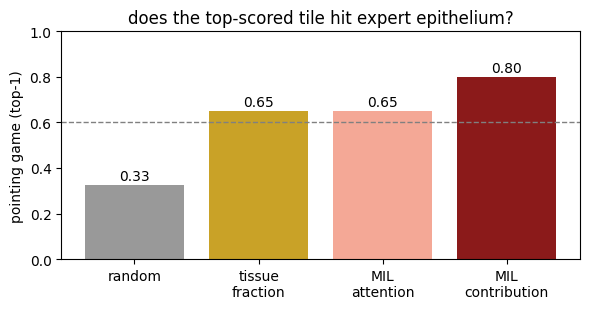

In [3]:
sc = g['scorers']
print(f"{'read-out':16s}  {'pointing top-1':22s} top3    top5    ranking AUC")
for nm in ['contribution', 'attention', 'tissue_fraction']:
    s = sc[nm]
    print(f"{nm:16s}  {s['top1']['mean']:.2f} [{s['top1']['ci95'][0]:.2f}-{s['top1']['ci95'][1]:.2f}]      "
          f"{s['top3']['mean']:.2f}    {s['top5']['mean']:.2f}    {s['auc']['mean']:.3f}")
print(f"{'random':16s}  {g['random_baseline']['top1']:.2f}                    "
      f"{g['random_baseline']['top3']:.2f}    {g['random_baseline']['top5']:.2f}    0.500")

fig, ax = plt.subplots(figsize=(6, 3.2))
labels = ['random', 'tissue\nfraction', 'MIL\nattention', 'MIL\ncontribution']
vals = [g['random_baseline']['top1'], sc['tissue_fraction']['top1']['mean'],
        sc['attention']['top1']['mean'], sc['contribution']['top1']['mean']]
ax.bar(labels, vals, color=['#999999', '#c9a227', TRAIN_COLOR, VAL_COLOR])
ax.set_ylabel('pointing game (top-1)'); ax.set_ylim(0, 1)
ax.axhline(0.60, ls='--', c='grey', lw=1); ax.set_title('does the top-scored tile hit expert epithelium?')
for i, v in enumerate(vals): ax.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.tight_layout(); plt.show()

The MIL contribution read-out puts the epithelium in its single top tile on 80% of slides, against
33% for random tile choice, and lands the epithelium in its top three on 95% of slides.

## 3. An honest look at the baseline

One caveat, reported plainly: the tissue-fraction baseline - rank tiles by how much tissue they
contain - is competitive on ranking AUC, and edges the MIL read-out there (0.824 vs 0.774). MIL wins
on the pointing game, the pre-registered success metric, because it concentrates its top pick on
epithelium rather than on whatever tile is fullest of tissue.

In [4]:
c, tf = sc['contribution'], sc['tissue_fraction']
print(f"                 pointing top-1     ranking AUC")
print(f"MIL contribution   {c['top1']['mean']:.2f}              {c['auc']['mean']:.3f}")
print(f"tissue fraction    {tf['top1']['mean']:.2f}              {tf['auc']['mean']:.3f}")
print()
print(f"MIL wins the pointing game by {c['top1']['mean'] - tf['top1']['mean']:.2f}; "
      f"tissue fraction wins AUC by {tf['auc']['mean'] - c['auc']['mean']:.3f}.")

                 pointing top-1     ranking AUC
MIL contribution   0.80              0.774
tissue fraction    0.65              0.824

MIL wins the pointing game by 0.15; tissue fraction wins AUC by 0.050.


## 4. Slide-level MIL classification

The same MIL model also gives a slide-level usable/unusable call (does any tile carry enough signal).
Recomputed here from mil_slide_preds.csv, donor-grouped 5-fold, and checked against the stored
aggregate.

In [5]:
rows = list(csv.DictReader(open(p("models", "mil", "mil_slide_preds.csv"), encoding="utf-8")))
CLASSES = ["unusable", "usable"]
def macro_f1(pairs):
    f1s = []
    for cls in CLASSES:
        tp = sum(1 for t, pr in pairs if t == cls and pr == cls)
        fp = sum(1 for t, pr in pairs if t != cls and pr == cls)
        fn = sum(1 for t, pr in pairs if t == cls and pr != cls)
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec = tp / (tp + fn) if tp + fn else 0.0
        f1s.append(2 * prec * rec / (prec + rec) if prec + rec else 0.0)
    return sum(f1s) / len(f1s)

by_fold = defaultdict(list)
for r in rows:
    by_fold[r["fold"]].append((r["TRUE"], r["pred"]))
fold_f1 = [macro_f1(by_fold[f]) for f in sorted(by_fold)]
mean_f1 = float(np.mean(fold_f1))
for i, f in enumerate(fold_f1, 1):
    print(f"  fold {i}: macro-F1 {f:.4f}")
print(f"\nrecomputed mean macro-F1: {mean_f1:.4f}")
print(f"stored   mean macro-F1: {metrics['aggregate']['macro_f1_mean']:.4f}")

  fold 1: macro-F1 0.6674
  fold 2: macro-F1 0.6741
  fold 3: macro-F1 0.6976
  fold 4: macro-F1 0.6972
  fold 5: macro-F1 0.7756

recomputed mean macro-F1: 0.7024
stored   mean macro-F1: 0.7024


## 5. Check against the stored evaluation

Recompute the pass/fail of the pre-registered success criteria straight from the numbers, and
reconcile the recomputed slide-level score with the stored aggregate.

In [6]:
c1 = g['scorers']['contribution']['top1']['mean']
verify("pointing top-1 >= 0.60", c1 >= 0.60, True, source="mil_gold_eval.json")
verify("pointing beats random+0.20", c1 >= g['random_baseline']['top1'] + 0.20, True, source="mil_gold_eval.json")
verify("beats tissue-fraction (pointing)", c1 > g['scorers']['tissue_fraction']['top1']['mean'], True, source="mil_gold_eval.json")
verify("all stored success criteria true", all(g['success_criteria'].values()), True, source="mil_gold_eval.json")
verify("slide macro-F1 reproduces stored", round(mean_f1, 3), round(metrics['aggregate']['macro_f1_mean'], 3),
       tol=0.005, source="mil_metrics.json")
verify_summary()

  ✓  pointing top-1 >= 0.60: computed True  expected True   [mil_gold_eval.json]
  ✓  pointing beats random+0.20: computed True  expected True   [mil_gold_eval.json]
  ✓  beats tissue-fraction (pointing): computed True  expected True   [mil_gold_eval.json]
  ✓  all stored success criteria true: computed True  expected True   [mil_gold_eval.json]
  ✓  slide macro-F1 reproduces stored: computed 0.702  expected 0.702   [mil_metrics.json]

VERIFICATION: 5/5 checks passed
